In [31]:
import networkx as nx
import matplotlib.pyplot as plt
import cvxpy as cp

In [32]:
depot = 0
schools = [1]

C:\Users\diego\AppData\Local\Temp\ipykernel_16524\4103280198.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


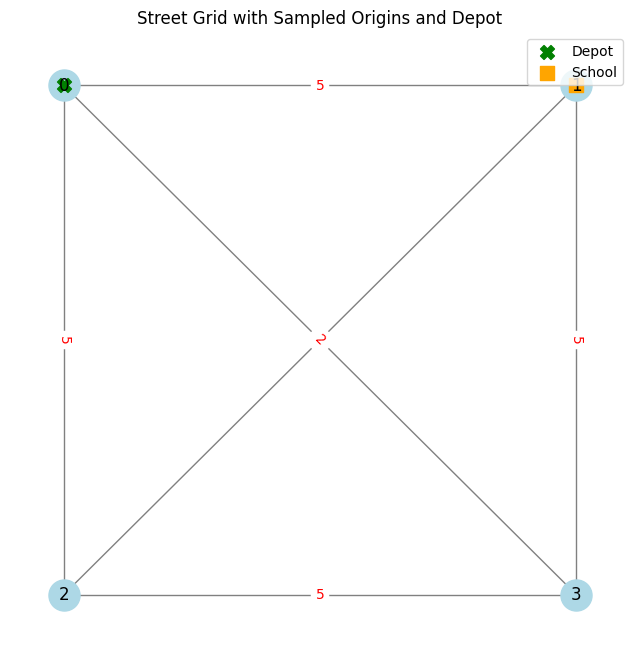

In [33]:
g = nx.Graph()
node_mapping = {}  # Map (row, col) to a unique integer
counter = 0

for i in range(2):
    for j in range(2):
        node_mapping[(i, j)] = counter
        counter += 1

for i in range(2):
    for j in range(2):
        if i > 0:
            g.add_edge(node_mapping[(i, j)], node_mapping[(i - 1, j)], weight=5)
        if j > 0:
            g.add_edge(node_mapping[(i, j)], node_mapping[(i, j - 1)], weight=5)

g.add_edge(node_mapping[(0, 0)], node_mapping[(1, 1)], weight=2)  # Diagonal edge with different weight
g.add_edge(node_mapping[(0, 1)], node_mapping[(1, 0)], weight=2)  # Another diagonal edge with different weight

# Add length attribute to edges
for u, v in g.edges():
    g.edges[u, v]['length'] = 1

# Generate positions for nodes (2D grid layout)
pos = {node_mapping[(x, y)]: (y, -x) for x, y in node_mapping.keys()}

# Randomly sample 20 points in the 2D space [min(p[0]), max(p[0])] x [min(p[1]), max(p[1])] for p in pos.values()
origins = []

g.nodes[2]['demand'] = 5
# in the future, make mapping using dict
student_mapping = {(2,schools[0]): 5}

# Visualize the graph and sampled points
fig, ax = plt.subplots(figsize=(8,8))
# label edges with weights
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in g.edges(data=True)}
nx.draw(g, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, ax=ax)
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_color='red', ax=ax)

# Plot the depot and schools
ax.scatter(pos[depot][0], pos[depot][1], color='green', s=100, label='Depot', marker='X', zorder=2)
for school in schools:
    ax.scatter(pos[school][0], pos[school][1], color='orange', s=100, label='School', marker='s', zorder=2)

ax.legend()
ax.set_title('Street Grid with Sampled Origins and Depot')
fig.show()

In [34]:
target = schools[0]

edges = list(g.edges())
m = len(edges)

x = cp.Variable(m, boolean=True)

weights = [g.edges[edge]['weight'] for edge in edges]
objective = cp.Minimize(cp.sum(cp.multiply(weights, x)))

constraints = []

for v in g.nodes():
    # For each node, collect indices of incident edges and their direction
    inc_indices = []
    inc_signs = []  # +1 if edge points into v, -1 if edge leaves v (arbitrary orientation)

    for idx, (u, w) in enumerate(edges):
        if v == u:
            inc_indices.append(idx)
            inc_signs.append(-1)  # treat (v -> w) as leaving v
        elif v == w:
            inc_indices.append(idx)
            inc_signs.append(+1)  # treat (u -> v) as entering v

    if v == depot:
        # net flow out of depot = +1
        constraints.append(cp.sum(cp.multiply(inc_signs, cp.hstack([x[i] for i in inc_indices]))) == 1)
    elif v == target:
        # net flow into target = +1  (equivalently, net flow out = -1)
        constraints.append(cp.sum(cp.multiply(inc_signs, cp.hstack([x[i] for i in inc_indices]))) == -1)
    else:
        # intermediate nodes have flow conservation = 0
        constraints.append(cp.sum(cp.multiply(inc_signs, cp.hstack([x[i] for i in inc_indices]))) == 0)

In [37]:
prob = cp.Problem(objective, constraints)
print("Solving MILP")
try:
    # Try with verbose to see progress; set a reasonable time limit
    prob.solve(solver=cp.GLPK_MI, verbose=True, glpk={'msg_lev': 'GLP_MSG_ON', 'tm_lim': 2*60*1000})  # 2-min limit
except Exception as e:
    print(f"⚠️  GLPK_MI failed or unavailable: {e}")
    print("Trying CBC as fallback...")
    try:
        prob.solve(solver=cp.CBC, verbose=True, maximumSeconds=120)
    except Exception as e2:
        print(f"⚠️  CBC also failed: {e2}")
        print("Trying default solver...")
        prob.solve(verbose=True)

print()
print("Status:", prob.status)
print("Objective (total distance):", prob.value)

(CVXPY) Feb 25 10:36:11 AM: Your problem has 6 variables, 4 constraints, and 0 parameters.
(CVXPY) Feb 25 10:36:11 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 25 10:36:11 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 25 10:36:11 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 25 10:36:11 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 25 10:36:11 AM: Compiling problem (target solver=GLPK_MI).
(CVXPY) Feb 25 10:36:11 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GLPK_MI
(CVXPY) Feb 25 10:36:11 AM: Applying reduction Dcp2Cone
(CVXPY) Feb 25 10:36:11 AM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 25 10:36:11 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 25 10:36:11 AM: Applying reduction GLPK_MI
(CVXPY) Feb 25 10:36:11 AM: Finished problem compilation (

Solving MILP
                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

Status: optimal
Objective (total distance): 5.0


In [38]:
# Extract and print the route
if prob.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
    print(f"⚠️ Solver did not find a feasible solution (status={prob.status}).")
else:
    print("Selected edges in the route:")
    selected_edges = [e for i, e in enumerate(edges) if x.value[i] > 0.5]
    for edge in selected_edges:
        i, j = edge
        print(f"Edge ({i}, {j}) with weight {g.edges[i, j]['weight']}")

Selected edges in the route:
Edge (1, 0) with weight 5


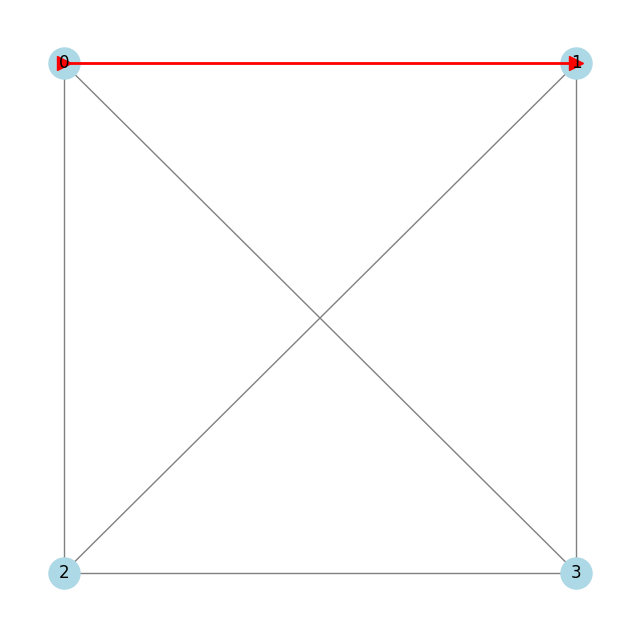

In [40]:
# Plot routes chosen by the solver
fig, ax = plt.subplots(figsize=(8,8))
nx.draw(g, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, ax=ax)
ax.scatter(pos[depot][0], pos[depot][1], color='green', s=100, label='Depot', marker='X')
for edge in selected_edges: 
    i, j = edge
    if x[edges.index(edge)].value is not None and x[edges.index(edge)].value > 0.5:  # Assuming binary variables
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], color='red', linewidth=2, marker=">", markersize=10)